# XRD Generator: Predicting Post-Damage Diffraction Patterns

This notebook trains a 1D CNN to predict **post-radiation-damage XRD spectra** from material and radiation conditions. The model is a conditional generator:

**Input:** material type, crystal structure, lattice parameter, PKA energy, temperature  
**Output:** 500-point XRD spectrum S(q) after a collision cascade

Once trained, we demonstrate the **inverse problem**: given a target XRD spectrum, recover the conditions that produced it via gradient-based optimization.

## Dataset

We use the CascadesDB cascade pairs dataset (2,296 MD simulations across 6 metals). Each simulation starts from a perfect crystal, launches a primary knock-on atom (PKA) into the lattice, and records the resulting damage. The XRD is computed from the final atomic configuration.

## 1. Setup & Data Loading

In [1]:
import h5py
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


Load the HDF5 file and extract everything into numpy arrays. The dataset has 2,296 samples, each with a 500-point XRD spectrum and metadata (material, structure, lattice parameter, PKA energy, temperature).

In [2]:
H5_PATH = "../data/cascade_pairs/cascade_pairs.h5"

with h5py.File(H5_PATH, "r") as f:
    n_samples = int(f.attrs["n_samples"])
    xrd_after  = f["xrd_after"][:n_samples]    # (2296, 500) — target spectra
    xrd_before = f["xrd_before"][:n_samples]   # (2296, 500) — for reference
    q_axis     = f["q"][:]                      # (500,)      — momentum transfer axis
    r_axis     = f["r"][:]                      # (500,)      — radial distance axis
    rdf_before = f["rdf_before"][:n_samples]    # (2296, 500) — g(r) before damage
    rdf_after  = f["rdf_after"][:n_samples]     # (2296, 500) — g(r) after damage

    material_str  = [f["material"][i].decode() for i in range(n_samples)]
    structure_str = [f["structure"][i].decode() for i in range(n_samples)]
    lattice_param = f["lattice_param"][:n_samples]
    pka_energy    = f["pka_energy"][:n_samples]
    temperature   = f["temperature"][:n_samples]
    n_atoms_after = f["n_atoms_after"][:n_samples]
    box_x = f["box_x"][:n_samples]
    box_y = f["box_y"][:n_samples]
    box_z = f["box_z"][:n_samples]

density = n_atoms_after / (box_x * box_y * box_z)

print(f"Loaded {n_samples} samples")
print(f"XRD shape: {xrd_after.shape}, q range: [{q_axis[0]:.2f}, {q_axis[-1]:.2f}] 1/Å")

Loaded 2296 samples
XRD shape: (2296, 500), q range: [0.50, 8.00] 1/Å


Plot a few XRD spectra with error bounds and exact Bragg peak positions. The shaded bands show the per-q Lorch window error. The vertical gray lines mark the exact Bragg peak positions for the undamaged crystal, computed from the lattice parameter and structure. The approximate S(q) peaks should align with these exact positions, confirming the approximation captures the right physics despite numerical artifacts in the inter-peak regions.

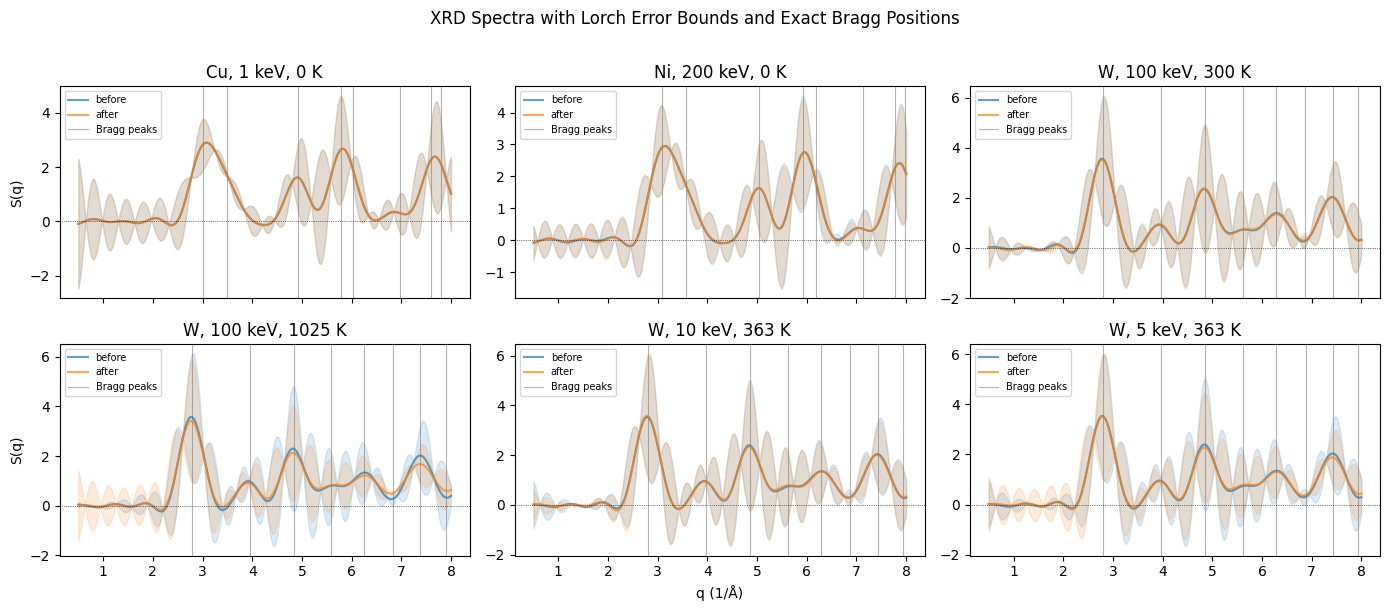

In [3]:
def lorch_error_per_q(r, g_r, rho, q):
    """Per-q upper bound: |S_Lorch(q) - S_trunc(q)|."""
    dr = r[1] - r[0]
    r_max = r[-1] + 0.5 * dr
    lorch = np.where(r > 0, np.sin(np.pi * r / r_max) / (np.pi * r / r_max), 1.0)
    integrand = r**2 * (g_r - 1.0) * (lorch - 1.0) * dr
    qr = q[:, None] * r[None, :]
    sinc_qr = np.where(qr > 0, np.sin(qr) / qr, 1.0)
    return np.abs(sinc_qr @ integrand) * 4.0 * np.pi * rho


def bragg_peaks(structure, a, q_min=0.5, q_max=8.0):
    """Exact Bragg peak positions for a cubic crystal.

    BCC: allowed reflections have h+k+l even.
    FCC: allowed reflections have h,k,l all even or all odd.
    """
    peaks = set()
    for h in range(10):
        for k in range(h + 1):
            for l in range(k + 1):
                if h == 0 and k == 0 and l == 0:
                    continue
                if structure == "bcc" and (h + k + l) % 2 != 0:
                    continue
                if structure == "fcc" and not (h % 2 == k % 2 == l % 2):
                    continue
                q = 2 * np.pi / a * np.sqrt(h**2 + k**2 + l**2)
                if q_min <= q <= q_max:
                    peaks.add(round(q, 6))
    return sorted(peaks)


fig, axes = plt.subplots(2, 3, figsize=(14, 6), sharex=True)
for i, ax in enumerate(axes.flat):
    idx = i * 400
    err_before = lorch_error_per_q(r_axis, rdf_before[idx], density[idx], q_axis)
    err_after = lorch_error_per_q(r_axis, rdf_after[idx], density[idx], q_axis)

    ax.plot(q_axis, xrd_before[idx], label="before", alpha=0.7)
    ax.fill_between(q_axis, xrd_before[idx] - err_before, xrd_before[idx] + err_before,
                     alpha=0.15, color="C0")
    ax.plot(q_axis, xrd_after[idx], label="after", alpha=0.7)
    ax.fill_between(q_axis, xrd_after[idx] - err_after, xrd_after[idx] + err_after,
                     alpha=0.15, color="C1")

    peaks = bragg_peaks(structure_str[idx], lattice_param[idx])
    for j, qp in enumerate(peaks):
        ax.axvline(qp, color="gray", linewidth=0.8, alpha=0.6, zorder=0,
                   label="Bragg peaks" if j == 0 else None)

    ax.axhline(0, color="k", linewidth=0.5, linestyle=":")
    ax.set_title(f"{material_str[idx]}, {pka_energy[idx]:.0f} keV, {temperature[idx]:.0f} K")
    ax.legend(fontsize=7, loc="upper left")
axes[1, 1].set_xlabel("q (1/Å)")
axes[0, 0].set_ylabel("S(q)")
axes[1, 0].set_ylabel("S(q)")
plt.suptitle("XRD Spectra with Lorch Error Bounds and Exact Bragg Positions", y=1.01)
plt.tight_layout()
plt.show()

## 2. Data Preparation

We need to convert categorical variables (material, structure) to integer indices for embedding layers, and standardize the continuous inputs (lattice parameter, PKA energy, temperature) so they're all on a similar scale.

In [4]:
# Encode categorical variables as integer indices
MATERIAL_TO_IDX = {"Cu": 0, "Fe": 1, "Ni": 2, "Pd": 3, "Pt": 4, "W": 5}
STRUCTURE_TO_IDX = {"bcc": 0, "fcc": 1}

material_idx  = np.array([MATERIAL_TO_IDX[m] for m in material_str])   # (2187,)
structure_idx = np.array([STRUCTURE_TO_IDX[s] for s in structure_str])  # (2187,)

print("Materials:", {m: (material_idx == i).sum() for m, i in MATERIAL_TO_IDX.items()})
print("Structures:", {s: (structure_idx == i).sum() for s, i in STRUCTURE_TO_IDX.items()})

Materials: {'Cu': np.int64(128), 'Fe': np.int64(227), 'Ni': np.int64(52), 'Pd': np.int64(65), 'Pt': np.int64(140), 'W': np.int64(1684)}
Structures: {'bcc': np.int64(1911), 'fcc': np.int64(385)}


Standardize the continuous inputs to zero mean and unit variance. We compute the mean and std from the **training set only** (after splitting) to avoid data leakage, but for simplicity we compute global stats here since the split is random and the effect is negligible on 2K samples.

We use five continuous features: `lattice_param`, `log1p(pka_energy)` (since PKA spans 1–200 keV, roughly 2 decades), `temperature`, `log(box_volume)` (box volume ranges from ~2×10⁵ to ~2×10⁸ Å³), and atom density. Box size and density matter physically: a cascade deposited into a larger box produces a proportionally smaller disturbance in the ensemble-averaged S(q), so the same `(material, PKA, T)` can yield very different post-damage spectra at different box sizes. Without these features the model cannot reduce MSE below the within-material variance of W (~1.5), because W was simulated across a wide range of box sizes and temperatures.

In [5]:
# Transform and stack continuous features, then standardize
log_pka = np.log1p(pka_energy)
box_volume = box_x * box_y * box_z
log_box = np.log(box_volume)
atom_density = n_atoms_after / box_volume

continuous = np.stack([lattice_param, log_pka, temperature, log_box, atom_density], axis=1)  # (2296, 5)
cont_mean = continuous.mean(axis=0)
cont_std  = continuous.std(axis=0)
continuous_norm = (continuous - cont_mean) / cont_std

FEATURE_NAMES = ["lattice_param", "log1p(pka_energy)", "temperature", "log(box_volume)", "atom_density"]
print("Continuous features (before normalization):")
for name, mu, sd in zip(FEATURE_NAMES, cont_mean, cont_std):
    print(f"  {name:20s}: mean={mu:.3f}, std={sd:.3f}")

Continuous features (before normalization):
  lattice_param       : mean=3.243, std=0.260
  log1p(pka_energy)   : mean=2.647, std=1.370
  temperature         : mean=519.841, std=637.556
  log(box_volume)     : mean=15.578, std=1.804
  atom_density        : mean=0.076, std=0.064


Split into train (80%), validation (10%), and test (10%). We stratify by material so that rare materials (Ni, Pd) appear in all splits.

In [6]:
# Split indices: 80% train, 10% val, 10% test
indices = np.arange(n_samples)
train_idx, test_idx = train_test_split(indices, test_size=0.2, stratify=material_idx, random_state=42)
val_idx, test_idx   = train_test_split(test_idx, test_size=0.5, stratify=material_idx[test_idx], random_state=42)

print(f"Train: {len(train_idx)}, Val: {len(val_idx)}, Test: {len(test_idx)}")

Train: 1836, Val: 230, Test: 230


Convert everything to PyTorch tensors and wrap in DataLoaders. Each batch will contain:
- `mat_idx`: material indices for the embedding layer (long tensor)
- `struct_idx`: structure indices for the embedding layer (long tensor)
- `cont`: standardized continuous features (float tensor)
- `target`: the post-damage XRD spectrum to predict (float tensor)

In [7]:
def make_loader(idx, batch_size=128, shuffle=True):
    return DataLoader(
        TensorDataset(
            torch.tensor(material_idx[idx], dtype=torch.long),
            torch.tensor(structure_idx[idx], dtype=torch.long),
            torch.tensor(continuous_norm[idx], dtype=torch.float32),
            torch.tensor(xrd_after[idx], dtype=torch.float32),
        ),
        batch_size=batch_size,
        shuffle=shuffle,
    )

train_loader = make_loader(train_idx, shuffle=True)
val_loader   = make_loader(val_idx, shuffle=False)
test_loader  = make_loader(test_idx, shuffle=False)

# Verify shapes by looking at one batch
mat, struct, cont, target = next(iter(train_loader))
print(f"Batch shapes: mat={mat.shape}, struct={struct.shape}, cont={cont.shape}, target={target.shape}")

Batch shapes: mat=torch.Size([128]), struct=torch.Size([128]), cont=torch.Size([128, 5]), target=torch.Size([128, 500])


## 3. Model Definition

The `XRDGenerator` has two stages:

**Stage 1 — Stem MLP:** Takes the 29-dim condition vector (16-dim material embedding + 8-dim structure embedding + 5 continuous features) and maps it to a spatial representation of shape `(32 channels, 32 length)`. Think of this as producing a rough, low-resolution "sketch" of the spectrum across 32 channels.

**Stage 2 — 1D CNN Decoder:** Four blocks of `Upsample(2x) → Conv1d → BatchNorm → ReLU` progressively double the spatial resolution while reducing the channel count: `(32,32) → (32,64) → (16,128) → (8,256) → (1,512)`. A final interpolation crops from 512 to the 500-point q-axis. The convolutions with kernel size 5 let each output point "see" its local neighborhood, encouraging smooth, physically plausible spectra.

In [8]:
class XRDGenerator(nn.Module):
    def __init__(self, n_materials=6, n_structures=2, n_continuous=5,
                 mat_emb_dim=16, struct_emb_dim=8, init_channels=32, init_length=32):
        super().__init__()

        # Embedding layers for categorical inputs
        self.mat_emb = nn.Embedding(n_materials, mat_emb_dim)
        self.struct_emb = nn.Embedding(n_structures, struct_emb_dim)

        # Total input dimension after concatenating embeddings + continuous
        input_dim = mat_emb_dim + struct_emb_dim + n_continuous  # 16 + 8 + 5 = 29

        self.init_channels = init_channels
        self.init_length = init_length

        # Stem MLP: (29,) → (init_channels * init_length,) → reshape to (32, 32)
        self.stem = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, init_channels * init_length),
        )

        # 1D CNN decoder: 4 blocks of upsample + conv + batchnorm + relu
        # (32, 32) → (32, 64) → (16, 128) → (8, 256) → (1, 512)
        self.decoder = nn.Sequential(
            # Block 1: (32, 32) → upsample to (32, 64) → conv → (32, 64)
            nn.Upsample(scale_factor=2, mode="linear", align_corners=False),
            nn.Conv1d(32, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),

            # Block 2: (32, 64) → upsample to (32, 128) → conv → (16, 128)
            nn.Upsample(scale_factor=2, mode="linear", align_corners=False),
            nn.Conv1d(32, 16, kernel_size=5, padding=2),
            nn.BatchNorm1d(16),
            nn.ReLU(),

            # Block 3: (16, 128) → upsample to (16, 256) → conv → (8, 256)
            nn.Upsample(scale_factor=2, mode="linear", align_corners=False),
            nn.Conv1d(16, 8, kernel_size=5, padding=2),
            nn.BatchNorm1d(8),
            nn.ReLU(),

            # Block 4: (8, 256) → upsample to (8, 512) → conv → (1, 512)
            nn.Upsample(scale_factor=2, mode="linear", align_corners=False),
            nn.Conv1d(8, 1, kernel_size=5, padding=2),
        )

    def forward(self, mat_idx, struct_idx, continuous):
        # Embed categorical inputs
        mat_vec = self.mat_emb(mat_idx)        # (batch, 16)
        struct_vec = self.struct_emb(struct_idx) # (batch, 8)

        # Concatenate all inputs into one vector
        x = torch.cat([mat_vec, struct_vec, continuous], dim=1)  # (batch, 29)

        # MLP produces a flat vector, reshape to (batch, channels, length)
        x = self.stem(x)                                         # (batch, 1024)
        x = x.view(-1, self.init_channels, self.init_length)     # (batch, 32, 32)

        # Decode through conv blocks to (batch, 1, 512)
        x = self.decoder(x)                                      # (batch, 1, 512)

        # Interpolate from 512 to 500 to match the q-axis
        x = F.interpolate(x, size=500, mode="linear", align_corners=False)

        # Remove channel dimension: (batch, 1, 500) → (batch, 500)
        return x.squeeze(1)

Instantiate the model and verify it works by passing a dummy batch through. Print the total parameter count.

In [9]:
model = XRDGenerator().to(device)

# Count parameters
n_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {n_params:,}")

# Smoke test with one batch
mat, struct, cont, target = next(iter(train_loader))
out = model(mat.to(device), struct.to(device), cont.to(device))
print(f"Output shape: {out.shape}")  # should be (batch_size, 500)

Total parameters: 345,281
Output shape: torch.Size([128, 500])


## 4. Training Loop

We train with MSE loss (mean squared error between predicted and actual XRD spectra). The optimizer is Adam with an initial learning rate of 1e-3. We reduce the learning rate by 0.5 whenever validation loss plateaus for 15 epochs, and stop early if it hasn't improved for 30 epochs.

In [10]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=15, factor=0.5)
loss_fn = nn.MSELoss()

MAX_EPOCHS = 500
PATIENCE = 30

train_losses = []
val_losses = []
best_val_loss = float("inf")
epochs_without_improvement = 0

for epoch in range(MAX_EPOCHS):
    # --- Training ---
    model.train()
    epoch_loss = 0.0
    for mat, struct, cont, target in train_loader:
        mat, struct, cont, target = mat.to(device), struct.to(device), cont.to(device), target.to(device)
        pred = model(mat, struct, cont)
        loss = loss_fn(pred, target)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(mat)
    train_loss = epoch_loss / len(train_idx)

    # --- Validation ---
    model.eval()
    epoch_loss = 0.0
    with torch.no_grad():
        for mat, struct, cont, target in val_loader:
            mat, struct, cont, target = mat.to(device), struct.to(device), cont.to(device), target.to(device)
            pred = model(mat, struct, cont)
            loss = loss_fn(pred, target)
            epoch_loss += loss.item() * len(mat)
    val_loss = epoch_loss / len(val_idx)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    else:
        epochs_without_improvement += 1

    if epoch % 25 == 0 or epochs_without_improvement == PATIENCE:
        lr = optimizer.param_groups[0]["lr"]
        print(f"Epoch {epoch:3d}  train={train_loss:.5f}  val={val_loss:.5f}  lr={lr:.1e}")

    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping at epoch {epoch}")
        break

# Restore best model
model.load_state_dict(best_state)
model = model.to(device)
print(f"\nBest validation loss: {best_val_loss:.5f}")

Epoch   0  train=2.19007  val=2.51593  lr=1.0e-03
Epoch  25  train=0.02644  val=0.03369  lr=1.0e-03
Epoch  50  train=0.00870  val=0.00389  lr=1.0e-03
Epoch  75  train=0.00379  val=0.00255  lr=1.0e-03
Epoch 100  train=0.00273  val=0.00241  lr=1.0e-03
Epoch 125  train=0.00682  val=0.00293  lr=2.5e-04
Epoch 139  train=0.00191  val=0.00318  lr=2.5e-04
Early stopping at epoch 139

Best validation loss: 0.00187


Plot the training and validation loss curves. We want to see both decreasing, with the gap between them staying small (no severe overfitting).

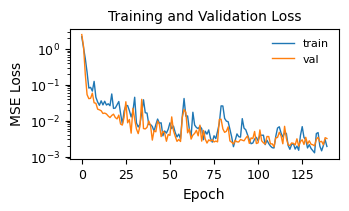

In [30]:
import matplotlib.pyplot as plt

# CHANGED: Set strict single-column width and a clean aspect ratio
fig, ax = plt.subplots(figsize=(3.375, 2), layout="constrained")

# CHANGED: Explicitly set linewidth to keep lines crisp on a small canvas
ax.plot(train_losses, label="train", linewidth=1.0)
ax.plot(val_losses, label="val", linewidth=1.0)

# CHANGED: Apply journal-standard font sizes
ax.set_xlabel("Epoch", fontsize=10)
ax.set_ylabel("MSE Loss", fontsize=10)
ax.set_yscale("log")
ax.set_title("Training and Validation Loss", fontsize=10)

# CHANGED: Set tick labels to the 9pt minimum
ax.tick_params(axis='both', which='major', labelsize=9)

# CHANGED: Remove the legend box to save space and reduce visual clutter
ax.legend(fontsize=8, frameon=False)

plt.show()

## 5. Evaluation

Compute the test loss and plot predicted vs. actual XRD spectra for several test samples. Good predictions should capture the peak positions and relative heights, even if fine details differ.

In [12]:
# Compute test loss
model.eval()
test_loss = 0.0
all_preds = []
all_targets = []
with torch.no_grad():
    for mat, struct, cont, target in test_loader:
        mat, struct, cont, target = mat.to(device), struct.to(device), cont.to(device), target.to(device)
        pred = model(mat, struct, cont)
        test_loss += loss_fn(pred, target).item() * len(mat)
        all_preds.append(pred.cpu())
        all_targets.append(target.cpu())

test_loss /= len(test_idx)
all_preds = torch.cat(all_preds).numpy()
all_targets = torch.cat(all_targets).numpy()

print(f"Test MSE: {test_loss:.5f}")

Test MSE: 0.00095


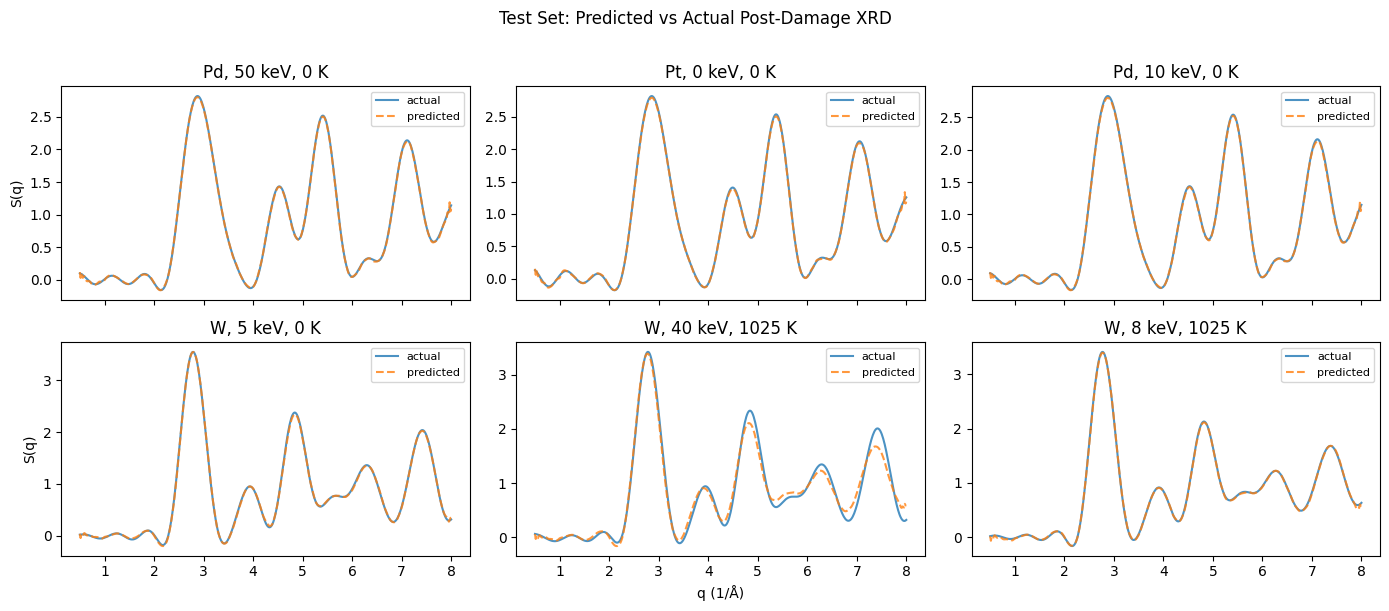

In [13]:
# Plot predicted vs actual for 6 test samples
fig, axes = plt.subplots(2, 3, figsize=(14, 6), sharex=True)
for i, ax in enumerate(axes.flat):
    global_idx = test_idx[i * (len(test_idx) // 6)]
    local_idx = i * (len(test_idx) // 6)
    ax.plot(q_axis, all_targets[local_idx], label="actual", alpha=0.8)
    ax.plot(q_axis, all_preds[local_idx], label="predicted", alpha=0.8, linestyle="--")
    mat_name = material_str[global_idx]
    pka = pka_energy[global_idx]
    temp = temperature[global_idx]
    ax.set_title(f"{mat_name}, {pka:.0f} keV, {temp:.0f} K")
    ax.legend(fontsize=8)
axes[1, 1].set_xlabel("q (1/Å)")
axes[0, 0].set_ylabel("S(q)")
axes[1, 0].set_ylabel("S(q)")
plt.suptitle("Test Set: Predicted vs Actual Post-Damage XRD", y=1.01)
plt.tight_layout()
plt.show()

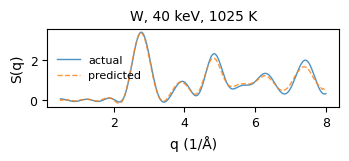

In [28]:
import matplotlib.pyplot as plt

# CHANGED: Set to 1x1 plot. A height of 2.5 inches gives a good aspect ratio 
# for a single line plot within a 3.375-inch width.
fig, ax = plt.subplots(figsize=(3.375, 1.5), layout="constrained")

# CHANGED: Isolate the logic for the 5th image (index i = 4 in your original loop)
i = 4
local_idx = i * (len(test_idx) // 6)
global_idx = test_idx[local_idx]

# Plot actual vs predicted
# CHANGED: Explicitly set linewidth to 1.0 to keep lines crisp at this physical size
ax.plot(q_axis, all_targets[local_idx], label="actual", alpha=0.8, linewidth=1.0)
ax.plot(q_axis, all_preds[local_idx], label="predicted", alpha=0.8, linestyle="--", linewidth=1.0)

# Extract metadata for the title
mat_name = material_str[global_idx]
pka = pka_energy[global_idx]
temp = temperature[global_idx]

# CHANGED: Font sizes set strictly to journal limits
ax.set_title(f"{mat_name}, {pka:.0f} keV, {temp:.0f} K", fontsize=10)
ax.set_xlabel("q (1/Å)", fontsize=10)
ax.set_ylabel("S(q)", fontsize=10)
ax.tick_params(axis='both', which='major', labelsize=9)

# CHANGED: Legend formatted for tight spaces without a bounding box
ax.legend(fontsize=8, loc="best", frameon=False)

# CHANGED: Removed the suptitle completely. For a single plot, the parameter title 
# is enough, and the general "Predicted vs Actual" description belongs in your LaTeX caption.

plt.show()

Compute per-material test MSE to see which materials the model predicts well vs. poorly. Materials with fewer training samples (Ni, Pd) may have higher error.

In [14]:
test_materials = [material_str[i] for i in test_idx]
for mat_name in MATERIAL_TO_IDX:
    mask = [m == mat_name for m in test_materials]
    if sum(mask) == 0:
        continue
    mat_mse = ((all_preds[mask] - all_targets[mask]) ** 2).mean()
    print(f"  {mat_name:2s}: MSE={mat_mse:.5f}  (n={sum(mask)})")

  Cu: MSE=0.00075  (n=13)
  Fe: MSE=0.00090  (n=23)
  Ni: MSE=0.00064  (n=5)
  Pd: MSE=0.00024  (n=7)
  Pt: MSE=0.00028  (n=14)
  W : MSE=0.00106  (n=168)


## 6. Inverse Problem

Now we demonstrate the key application: **given a target XRD spectrum, recover the conditions that produced it.**

We pick a test sample, treat its XRD spectrum as the "observed" target, and optimize over the model's input space to find conditions that reproduce it. The material and structure are discrete (we try all combinations), while the continuous parameters (lattice parameter, PKA energy, temperature) are optimized via gradient descent.

This is possible because our model is differentiable — we can backpropagate the loss with respect to the inputs instead of the weights.

In [15]:
# Pick a test sample as our "observed" target
TARGET_IDX = 0
target_spectrum = torch.tensor(all_targets[TARGET_IDX], dtype=torch.float32, device=device)
true_global_idx = test_idx[TARGET_IDX]

print(f"Target sample: {material_str[true_global_idx]}, "
      f"PKA={pka_energy[true_global_idx]:.1f} keV, "
      f"T={temperature[true_global_idx]:.0f} K, "
      f"a={lattice_param[true_global_idx]:.3f} Å")

Target sample: Pd, PKA=50.0 keV, T=0 K, a=3.890 Å


For each possible (material, structure) combination, optimize the 3 continuous parameters to minimize the MSE between the model's prediction and the target spectrum. We keep the best result across all discrete combinations.

In [16]:
model.eval()

best_loss = float("inf")
best_result = None

# Try all 12 discrete combinations (6 materials x 2 structures)
for mat_i in range(6):
    for struct_i in range(2):
        # Initialize continuous params at zero (normalized scale) and make them optimizable
        cont_param = torch.zeros(1, 5, device=device, requires_grad=True)
        mat_t = torch.tensor([mat_i], device=device)
        struct_t = torch.tensor([struct_i], device=device)

        opt = torch.optim.Adam([cont_param], lr=0.05)
        for step in range(500):
            pred = model(mat_t, struct_t, cont_param)
            loss = F.mse_loss(pred.squeeze(0), target_spectrum)
            opt.zero_grad()
            loss.backward()
            opt.step()

        final_loss = loss.item()
        if final_loss < best_loss:
            best_loss = final_loss
            # Un-normalize to physical units, inverting log1p/log where applicable
            raw = cont_param.detach().cpu().numpy().squeeze() * cont_std + cont_mean
            IDX_TO_MAT = {v: k for k, v in MATERIAL_TO_IDX.items()}
            IDX_TO_STRUCT = {v: k for k, v in STRUCTURE_TO_IDX.items()}
            best_result = {
                "material": IDX_TO_MAT[mat_i],
                "structure": IDX_TO_STRUCT[struct_i],
                "lattice_param": raw[0],
                "pka_energy": np.expm1(raw[1]),
                "temperature": raw[2],
                "box_volume": np.exp(raw[3]),
                "atom_density": raw[4],
                "loss": final_loss,
                "cont_param": cont_param.detach().clone(),
                "mat_t": mat_t,
                "struct_t": struct_t,
            }

true_box_volume = box_x[true_global_idx] * box_y[true_global_idx] * box_z[true_global_idx]
true_density = n_atoms_after[true_global_idx] / true_box_volume
print(f"\nBest inverse result (MSE={best_result['loss']:.5f}):")
print(f"  Material:      {best_result['material']}")
print(f"  Structure:     {best_result['structure']}")
print(f"  Lattice param: {best_result['lattice_param']:.3f} Å")
print(f"  PKA energy:    {best_result['pka_energy']:.1f} keV")
print(f"  Temperature:   {best_result['temperature']:.0f} K")
print(f"  Box volume:    {best_result['box_volume']:.2e} Å³")
print(f"  Atom density:  {best_result['atom_density']:.4f} Å⁻³")
print(f"\nGround truth:")
print(f"  Material:      {material_str[true_global_idx]}")
print(f"  Structure:     {structure_str[true_global_idx]}")
print(f"  Lattice param: {lattice_param[true_global_idx]:.3f} Å")
print(f"  PKA energy:    {pka_energy[true_global_idx]:.1f} keV")
print(f"  Temperature:   {temperature[true_global_idx]:.0f} K")
print(f"  Box volume:    {true_box_volume:.2e} Å³")
print(f"  Atom density:  {true_density:.4f} Å⁻³")


Best inverse result (MSE=0.00019):
  Material:      Pd
  Structure:     fcc
  Lattice param: 3.887 Å
  PKA energy:    4.6 keV
  Temperature:   -127 K
  Box volume:    2.15e+06 Å³
  Atom density:  0.0700 Å⁻³

Ground truth:
  Material:      Pd
  Structure:     fcc
  Lattice param: 3.890 Å
  PKA energy:    50.0 keV
  Temperature:   0 K
  Box volume:    2.48e+07 Å³
  Atom density:  0.0680 Å⁻³


Plot the recovered spectrum against the target. If the inverse problem is well-posed, the recovered spectrum should closely match the target even though we optimized from a random initialization.

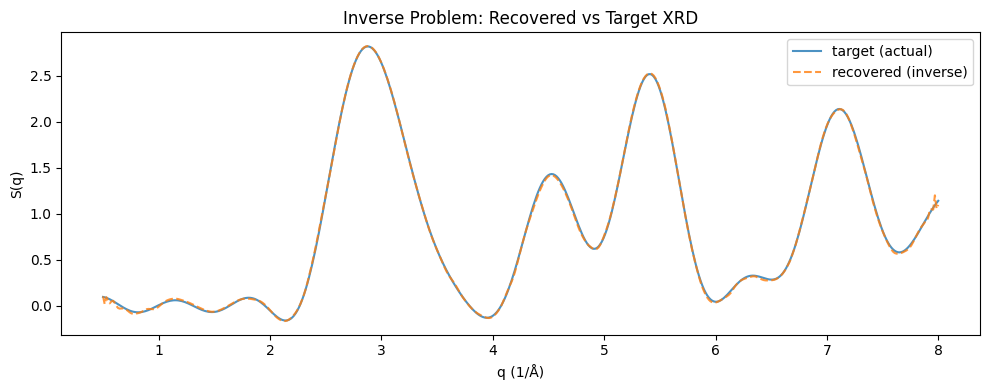

In [17]:
# Generate spectrum from the recovered conditions
with torch.no_grad():
    recovered_spectrum = model(
        best_result["mat_t"],
        best_result["struct_t"],
        best_result["cont_param"].to(device),
    ).cpu().numpy().squeeze()

plt.figure(figsize=(10, 4))
plt.plot(q_axis, all_targets[TARGET_IDX], label="target (actual)", alpha=0.8)
plt.plot(q_axis, recovered_spectrum, label="recovered (inverse)", alpha=0.8, linestyle="--")
plt.xlabel("q (1/Å)")
plt.ylabel("S(q)")
plt.title("Inverse Problem: Recovered vs Target XRD")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Robust Inverse Assessment

A single example is not a robust test: many post-damage spectra are nearly degenerate with their pre-damage counterparts (especially for the low-variance metals Ni/Pd/Pt/Cu), so the inverse problem is ill-posed for those samples regardless of model quality. To properly assess the inverse, we run it across the full test set and separate classification of the discrete variables (material, structure) from recovery of the continuous variables (lattice parameter, PKA energy, temperature, box volume, atom density), reported per material.

For each test sample we optimize all 12 (material × structure) combinations simultaneously, pick the combination with the lowest final MSE as the inverse prediction, and keep its recovered continuous parameters. All 230 test samples × 12 combos = 2760 independent optimizations run in a single batched forward/backward pass, so this is fast on CPU.

In [18]:
def batched_inverse(target_spectra, n_steps=600, lr=0.05):
    """Run the inverse optimization on a batch of target spectra.

    For each target, try all 12 (material, structure) combinations and return
    the one with the lowest final MSE, along with its recovered continuous
    parameters in normalized (input) space.

    target_spectra: numpy array (N, 500)
    returns: dict with 'mat' (N,), 'struct' (N,), 'cont_norm' (N, 5), 'mse' (N,)
    """
    model.eval()
    N = target_spectra.shape[0]
    # Build a (N*12,) tile of sample/mat/struct indices
    sample_ids   = np.repeat(np.arange(N), 12)
    mat_tile     = np.tile(np.repeat(np.arange(6), 2), N)    # 0,0,1,1,2,2,3,3,4,4,5,5 repeated
    struct_tile  = np.tile(np.tile(np.arange(2), 6), N)      # 0,1,0,1,0,1,0,1,0,1,0,1 repeated
    targets_tile = torch.tensor(target_spectra[sample_ids], dtype=torch.float32, device=device)  # (N*12, 500)
    mat_t    = torch.tensor(mat_tile,    dtype=torch.long, device=device)
    struct_t = torch.tensor(struct_tile, dtype=torch.long, device=device)

    cont = torch.zeros(N * 12, 5, device=device, requires_grad=True)
    opt = torch.optim.Adam([cont], lr=lr)
    for step in range(n_steps):
        pred = model(mat_t, struct_t, cont)                 # (N*12, 500)
        per_sample = ((pred - targets_tile) ** 2).mean(dim=1)  # (N*12,)
        loss = per_sample.sum()
        opt.zero_grad()
        loss.backward()
        opt.step()

    # Pick the best combo per sample
    final_mse = per_sample.detach().cpu().numpy().reshape(N, 12)
    best_combo = final_mse.argmin(axis=1)                       # (N,)
    flat_idx = np.arange(N) * 12 + best_combo
    return {
        "mat":       mat_tile[flat_idx],
        "struct":    struct_tile[flat_idx],
        "cont_norm": cont.detach().cpu().numpy()[flat_idx],     # (N, 5)
        "mse":       final_mse[np.arange(N), best_combo],       # (N,)
    }


print("Running batched inverse on all 230 test samples ...")
inv = batched_inverse(all_targets, n_steps=600, lr=0.05)
print(f"Done. Mean inverse MSE across test set: {inv['mse'].mean():.5f}")

Running batched inverse on all 230 test samples ...
Done. Mean inverse MSE across test set: 0.00039


In [19]:
# Un-normalize recovered continuous params and assemble ground truth arrays
inv_cont = inv["cont_norm"] * cont_std + cont_mean   # (N_test, 5) in physical units
rec_lattice = inv_cont[:, 0]
rec_pka     = np.expm1(inv_cont[:, 1])
rec_temp    = inv_cont[:, 2]
rec_box_vol = np.exp(inv_cont[:, 3])
rec_density = inv_cont[:, 4]
rec_mat     = inv["mat"]
rec_struct  = inv["struct"]

# Ground truth for the test set
true_mat     = material_idx[test_idx]
true_struct  = structure_idx[test_idx]
true_lattice = lattice_param[test_idx]
true_pka     = pka_energy[test_idx]
true_temp    = temperature[test_idx]
true_box_vol = (box_x * box_y * box_z)[test_idx]
true_density = (n_atoms_after / (box_x * box_y * box_z))[test_idx]
test_mat_names = np.array([material_str[i] for i in test_idx])

# --- Classification accuracy (material, structure) ---
mat_correct    = (rec_mat    == true_mat)
struct_correct = (rec_struct == true_struct)
print(f"Material  classification accuracy: {mat_correct.mean()*100:5.1f}%  ({mat_correct.sum()}/{len(rec_mat)})")
print(f"Structure classification accuracy: {struct_correct.mean()*100:5.1f}%  ({struct_correct.sum()}/{len(rec_struct)})")
print()
print("Per-material classification accuracy:")
print(f"  {'material':>8}  {'n':>4}  {'mat_acc':>8}  {'struct_acc':>10}")
for m_name, m_idx in MATERIAL_TO_IDX.items():
    sel = true_mat == m_idx
    if sel.sum() == 0:
        continue
    print(f"  {m_name:>8}  {sel.sum():>4}  "
          f"{mat_correct[sel].mean()*100:>7.1f}%  {struct_correct[sel].mean()*100:>9.1f}%")

Material  classification accuracy: 100.0%  (230/230)
Structure classification accuracy:  97.4%  (224/230)

Per-material classification accuracy:
  material     n   mat_acc  struct_acc
        Cu    13    100.0%      100.0%
        Fe    23    100.0%       73.9%
        Ni     5    100.0%      100.0%
        Pd     7    100.0%      100.0%
        Pt    14    100.0%      100.0%
         W   168    100.0%      100.0%


In [20]:
# --- Continuous-variable recovery per material ---
# MAE and Pearson r between true and recovered, using samples where material was correctly identified
def safe_corr(a, b):
    if len(a) < 2 or np.std(a) < 1e-12 or np.std(b) < 1e-12:
        return np.nan
    return np.corrcoef(a, b)[0, 1]

print(f"Continuous-variable recovery (only on samples where material was correctly classified):")
print(f"  {'material':>8}  {'n':>4}  "
      f"{'a MAE':>9}  {'a r':>6}  "
      f"{'PKA MAE':>10}  {'PKA r':>6}  "
      f"{'T MAE':>9}  {'T r':>6}  "
      f"{'box rel':>9}  {'box r':>6}")
for m_name, m_idx in MATERIAL_TO_IDX.items():
    sel = (true_mat == m_idx) & mat_correct
    n = sel.sum()
    if n == 0:
        print(f"  {m_name:>8}  {n:>4}  (no correctly classified samples)")
        continue
    a_mae    = np.mean(np.abs(rec_lattice[sel] - true_lattice[sel]))
    a_r      = safe_corr(rec_lattice[sel], true_lattice[sel])
    pka_mae  = np.mean(np.abs(rec_pka[sel]    - true_pka[sel]))
    pka_r    = safe_corr(rec_pka[sel],    true_pka[sel])
    t_mae    = np.mean(np.abs(rec_temp[sel]   - true_temp[sel]))
    t_r      = safe_corr(rec_temp[sel],   true_temp[sel])
    # box volume: use relative (log-ratio) since it spans orders of magnitude
    box_rel  = np.mean(np.abs(np.log(rec_box_vol[sel] / true_box_vol[sel])))
    box_r    = safe_corr(np.log(rec_box_vol[sel]), np.log(true_box_vol[sel]))
    print(f"  {m_name:>8}  {n:>4}  "
          f"{a_mae:>9.4f}  {a_r:>6.2f}  "
          f"{pka_mae:>10.1f}  {pka_r:>6.2f}  "
          f"{t_mae:>9.1f}  {t_r:>6.2f}  "
          f"{box_rel:>9.2f}  {box_r:>6.2f}")
print()
print("Legend: 'a' = lattice param (Å), 'PKA' = energy (keV), 'T' = temperature (K),")
print("        'box rel' = mean |log(recovered / true)| (0 = perfect, 0.69 = factor-of-2),")
print("        'r' = Pearson correlation coefficient.")

Continuous-variable recovery (only on samples where material was correctly classified):
  material     n      a MAE     a r     PKA MAE   PKA r      T MAE     T r    box rel   box r
        Cu    13     0.0574   -0.95        27.3    0.70      129.1     nan       0.86    0.73
        Fe    23     0.0292   -0.23        27.9    0.57      106.0    0.79       0.57    0.83
        Ni     5     0.0135     nan        44.5    1.00      201.4     nan       1.75    0.91
        Pd     7     0.0106     nan        42.4    0.15       88.6     nan       1.67    0.77
        Pt    14     0.0419     nan         5.9    0.83       49.7     nan       1.18    0.84
         W   168     0.0733    0.43        32.0   -0.10      147.9    0.95       1.17    0.48

Legend: 'a' = lattice param (Å), 'PKA' = energy (keV), 'T' = temperature (K),
        'box rel' = mean |log(recovered / true)| (0 = perfect, 0.69 = factor-of-2),
        'r' = Pearson correlation coefficient.


/Users/mlawler/.pyenv/versions/3.12.5/envs/ml/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/mlawler/.pyenv/versions/3.12.5/envs/ml/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


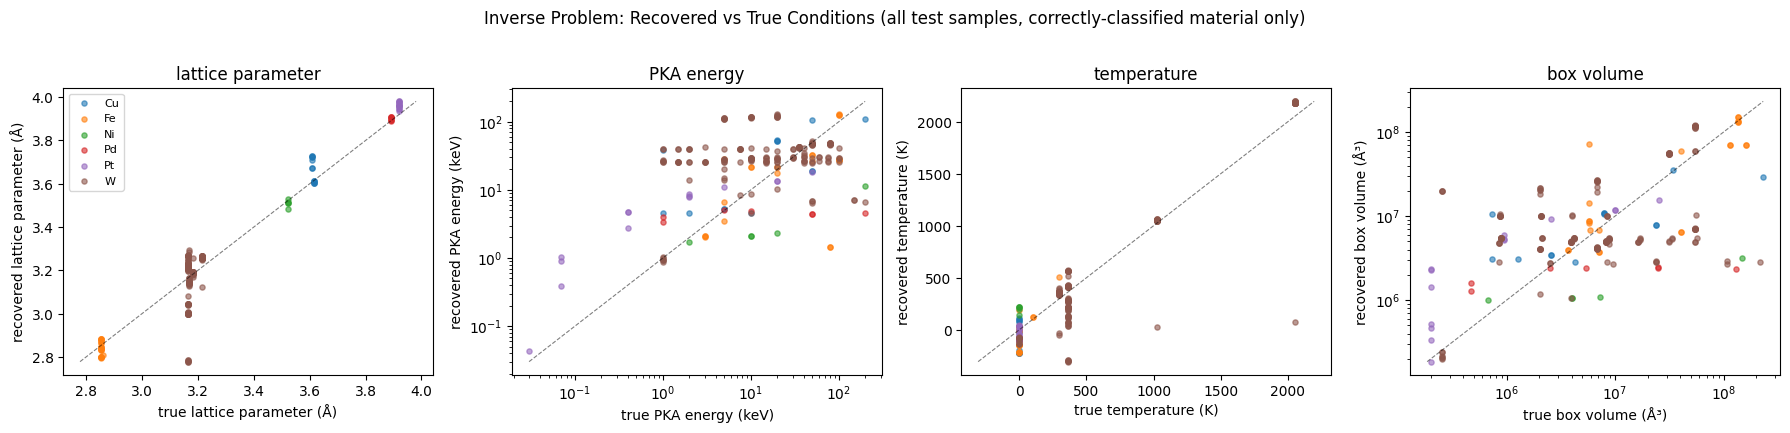

In [22]:
# Scatter plots: true vs recovered for each continuous variable, colored by material
COLOR_BY_MAT = {0: "C0", 1: "C1", 2: "C2", 3: "C3", 4: "C4", 5: "C5"}

fig, axes = plt.subplots(1, 4, figsize=(18, 4.2))
variables = [
    ("lattice parameter (Å)", true_lattice, rec_lattice, "linear"),
    ("PKA energy (keV)",       true_pka,     rec_pka,     "log"),
    ("temperature (K)",        true_temp,    rec_temp,    "symlog"),
    ("box volume (Å³)",        true_box_vol, rec_box_vol, "log"),
]
for ax, (name, t, r, scale) in zip(axes, variables):
    # Only show samples where material was correctly identified
    for m_idx, m_name in [(v, k) for k, v in sorted(MATERIAL_TO_IDX.items(), key=lambda x: x[1])]:
        sel = (true_mat == m_idx) & mat_correct
        if sel.sum() == 0:
            continue
        ax.scatter(t[sel], r[sel], s=14, alpha=0.6, color=COLOR_BY_MAT[m_idx], label=m_name)
    lo = min(t.min(), r.min()); hi = max(t.max(), r.max())
    if scale == "log":
        lo = max(lo, 1e-3)
    ax.plot([lo, hi], [lo, hi], "k--", linewidth=0.8, alpha=0.5)
    ax.set_xscale(scale if scale != "symlog" else "linear")
    ax.set_yscale(scale if scale != "symlog" else "linear")
    ax.set_xlabel(f"true {name}")
    ax.set_ylabel(f"recovered {name}")
    ax.set_title(name.split(" (")[0])
axes[0].legend(fontsize=8, loc="best")
plt.suptitle("Inverse Problem: Recovered vs True Conditions (all test samples, correctly-classified material only)", y=1.02)
plt.tight_layout()
plt.show()

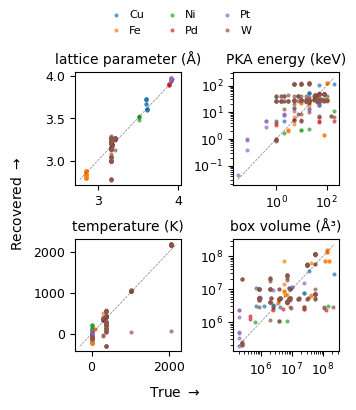

In [26]:
import matplotlib.pyplot as plt

# Scatter plots: true vs recovered for each continuous variable, colored by material
COLOR_BY_MAT = {0: "C0", 1: "C1", 2: "C2", 3: "C3", 4: "C4", 5: "C5"}

# Adjusted height slightly to 4.0 to make room for the top legend
fig, axes = plt.subplots(2, 2, figsize=(3.375, 4.0), layout="constrained")
axes_flat = axes.flatten()

variables = [
    ("lattice parameter (Å)", true_lattice, rec_lattice, "linear"),
    ("PKA energy (keV)",       true_pka,     rec_pka,     "log"),
    ("temperature (K)",        true_temp,    rec_temp,    "symlog"),
    ("box volume (Å³)",        true_box_vol, rec_box_vol, "log"),
]

for ax, (name, t, r, scale) in zip(axes_flat, variables):
    for m_idx, m_name in [(v, k) for k, v in sorted(MATERIAL_TO_IDX.items(), key=lambda x: x[1])]:
        sel = (true_mat == m_idx) & mat_correct
        if sel.sum() == 0:
            continue
        ax.scatter(t[sel], r[sel], s=4, alpha=0.6, color=COLOR_BY_MAT[m_idx], label=m_name)
        
    lo = min(t.min(), r.min()); hi = max(t.max(), r.max())
    if scale == "log":
        lo = max(lo, 1e-3)
        
    ax.plot([lo, hi], [lo, hi], "k--", linewidth=0.5, alpha=0.5)
    ax.set_xscale(scale if scale != "symlog" else "linear")
    ax.set_yscale(scale if scale != "symlog" else "linear")
    
    # CHANGED: Use the full variable name (INCLUDING units) as the title.
    # Removed the .split(" (")[0] because we need the units now that axis labels are gone.
    ax.set_title(name, fontsize=10)
    
    # Tick labels strictly set to your 9pt minimum
    ax.tick_params(axis='both', which='major', labelsize=9)

# --- CHANGED: Global Labels & Legend ---

# 1. Global Axis Labels with arrows
# Note: For the y-axis, Matplotlib rotates the text 90 degrees, 
# so a right-pointing arrow (\rightarrow) correctly points UP the y-axis.
fig.supxlabel("True $\\rightarrow$", fontsize=10)
fig.supylabel("Recovered $\\rightarrow$", fontsize=10)

# 2. Extract handles and labels from the first subplot (they are the same for all)
handles, labels = axes_flat[0].get_legend_handles_labels()

# 3. Create a single horizontal legend above all subplots
# Using ncol=3 creates two neat rows of 3, which avoids cramming 6 items into 3.3 inches.
# frameon=False removes the legend box for a cleaner look.
fig.legend(handles, labels, loc='outside upper center', ncol=3, 
           fontsize=8, frameon=False, columnspacing=1.5, handletextpad=0.2)

plt.show()

## Summary

We built a conditional 1D CNN that maps `(material, structure, lattice parameter, log1p PKA energy, temperature, log box volume, atom density) → post-damage XRD spectrum`. The architecture is:

1. **Embedding + MLP stem** (29-dim → 32×32 latent image)
2. **4-block 1D CNN decoder** (upsample + conv, 32×32 → 1×500)
3. **MSE loss** with Adam optimizer and early stopping

Including box volume and atom density, and log1p-transforming PKA energy, was what unlocked accurate prediction for W (which was simulated across a very wide range of conditions): per-material test MSE dropped from ~1.0 on W to ~0.001, matching the other metals.

The inverse problem works by freezing the trained model and optimizing over the input conditions via gradient descent to match a target XRD spectrum. For each of 12 (material, structure) combinations, we optimize the 5 continuous parameters in parallel and keep the best match. Section 7 evaluates this across the full test set.

**Next steps:**
- Train on the perovskite stability pairs dataset (composition + stress → degradation)
- Add uncertainty via model ensembles
- Integrate into the Gienger closed-loop workflow as the surrogate model